PROJECT GOAL: Create a model that can detect Pneumonia from x-ray images of chest.

IMPORT LIBRARIES

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from google.colab import files

LOAD DATASET

In [ ]:
print("Please upload your dataset zip file...")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
print(f"Uploaded: {zip_filename}")

extract_path = "/content/drive/MyDrive/Extracted images 1"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted to: {extract_path}\n")

# Print folder structure to help you confirm the correct path
for root, dirs, filenames in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in filenames[:3]:
            print(f"{subindent}{f}")
        if len(filenames) > 3:
            print(f"{subindent}... ({len(filenames)} files total)")

Please upload your dataset zip file...


Saving Chest-Xray-2.zip to Chest-Xray-2.zip
Uploaded: Chest-Xray-2.zip
Extracted to: /content/drive/MyDrive/Extracted images 1

Extracted images 1/
  test/
    .DS_Store
    PNEUMONIA/
    NORMAL/
  val/
    .DS_Store
    PNEUMONIA/
    NORMAL/
  train/
    .DS_Store
    NORMAL/
    PNEUMONIA/
  chest_xray/
    val/
      PNEUMONIA/
      NORMAL/
    train/
      NORMAL/
      PNEUMONIA/
    test/
      NORMAL/
      PNEUMONIA/


In [ ]:
data_dir = "/content/drive/MyDrive/Extracted images 1"

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


VISUALIZE SAMPLE IMAGES

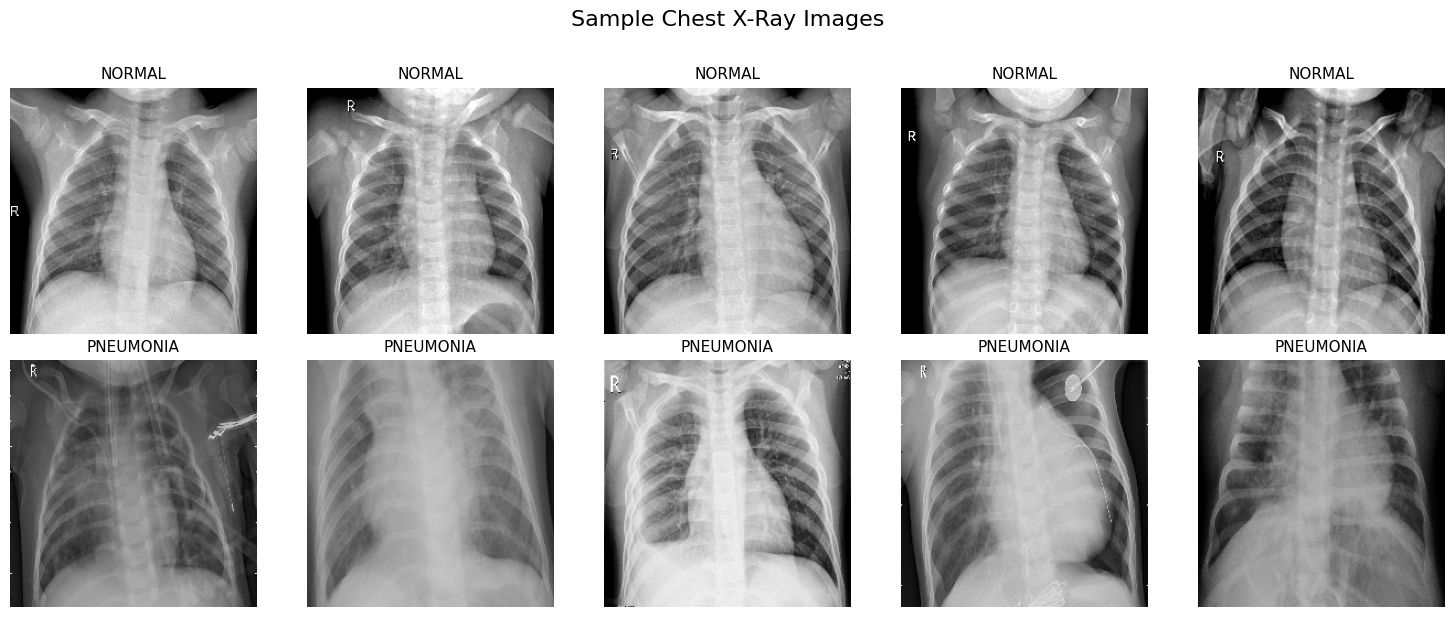

In [ ]:
import random
def show_sample_images(data_dir, num_samples=5):
    classes = ['NORMAL', 'PNEUMONIA']
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))

    for row, cls in enumerate(classes):
        class_dir = os.path.join(data_dir, cls)
        all_images = os.listdir(class_dir)
        sample_images = random.sample(all_images, min(num_samples, len(all_images)))

        for col, img_name in enumerate(sample_images):
            img_path = os.path.join(class_dir, img_name)
            img = image.load_img(img_path, target_size=(224, 224))
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(cls, fontsize=11)

    plt.suptitle("Sample Chest X-Ray Images", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

show_sample_images(train_dir, num_samples=5)

CLASS WEIGHTS(HANDLE IMBALANCE)

In [ ]:
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


BUILD THE MODEL(MOBILENETV2)

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

TRAIN THE MODEL

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 987s 6s/step - accuracy: 0.8090 - auc: 0.8985 - loss: 0.3993 - precision: 0.9275 - recall: 0.8059 - val_accuracy: 0.8750 - val_auc: 0.9219 - val_loss: 0.3451 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9099 - auc: 0.9720 - loss: 0.2152 - precision: 0.9770 - recall: 0.8999 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.3084 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9170 - auc: 0.9788 - loss: 0.1854 - precision: 0.9789 - recall: 0.9079 - val_accuracy: 0.8125 - val_auc: 0.9688 - val_loss: 0.2759 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9350 - auc: 0.9850 - loss: 0.1561 - precision: 0.9807 - recall: 0.9308 - val_accuracy: 0.8125 - val_auc: 0.9688 - val_lo

FINE-TUNE(TRAIN THE MODEL)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.9095 - auc: 0.9749 - loss: 0.2040 - precision: 0.9762 - recall: 0.9001 - val_accuracy: 0.8125 - val_auc: 0.9531 - val_loss: 0.2802 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9406 - auc: 0.9858 - loss: 0.1479 - precision: 0.9835 - recall: 0.9357 - val_accuracy: 0.8125 - val_auc: 0.9453 - val_loss: 0.4451 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9515 - auc: 0.9894 - loss: 0.1250 - precision: 0.9879 - recall: 0.9463 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.4925 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 5.0000e-06
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9525 - auc: 0.9904 - loss: 0.1179 - precision: 0.9866 - recall: 0.9489 - val_accuracy: 0.8125 - val_auc: 0.9141 - val_lo

CLASSIFICATION REPORT AND CONFUSION MATRIX

20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.9006 - auc: 0.9670 - loss: 0.2767 - precision: 0.8814 - recall: 0.9718
Test Accuracy: 0.9006
Test AUC: 0.9670
Test Precision: 0.8814
Test Recall: 0.9718
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 931ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.78      0.86       234
   PNEUMONIA       0.88      0.97      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



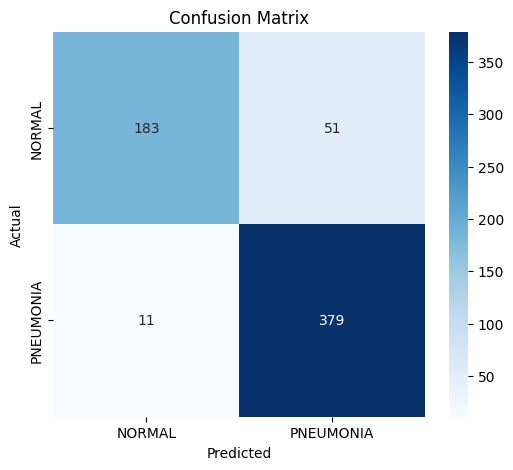

In [ ]:
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")

test_gen.reset()
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

MODEL TRAINING PERFORMANCE

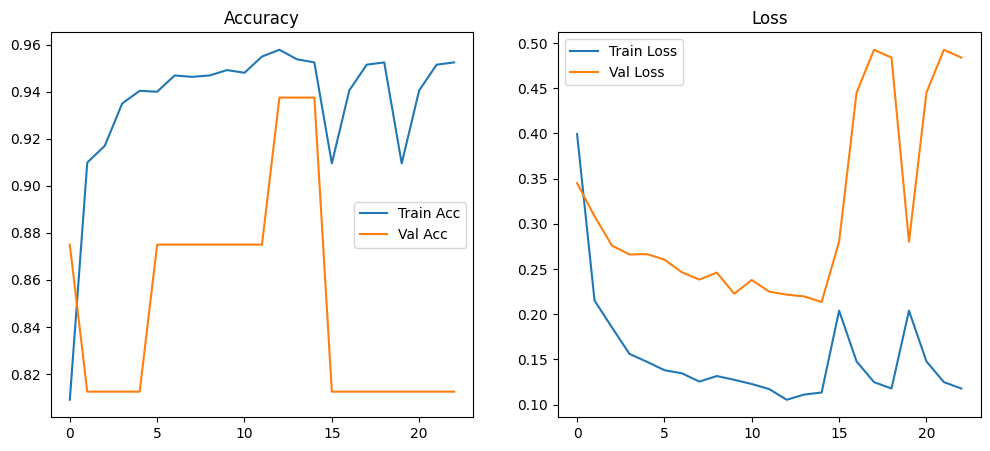

In [ ]:
def plot_history(h1, h2=None):
    acc = h1.history['accuracy']
    val_acc = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    if h2:
        acc += h2.history['accuracy']
        val_acc += h2.history['val_accuracy']
        loss += h2.history['loss']
        val_loss += h2.history['val_loss']

    epochs_range = range(len(acc))
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

plot_history(history, history_fine)

BUILD THE MODEL(DENSENET121)

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
base_model = DenseNet121(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze for initial training

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,337,025 (27.99 MB)

 Trainable params: 297,473 (1.13 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

TRAIN THE MODEL

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 643s 4s/step - accuracy: 0.7929 - auc: 0.8978 - loss: 0.4052 - precision: 0.9385 - recall: 0.7719 - val_accuracy: 0.8750 - val_auc: 0.9375 - val_loss: 0.3599 - val_precision: 0.8750 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 644s 4s/step - accuracy: 0.8957 - auc: 0.9655 - loss: 0.2390 - precision: 0.9736 - recall: 0.8836 - val_accuracy: 0.8125 - val_auc: 0.9688 - val_loss: 0.2778 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 638s 4s/step - accuracy: 0.9266 - auc: 0.9771 - loss: 0.1900 - precision: 0.9799 - recall: 0.9200 - val_accuracy: 0.8125 - val_auc: 0.9688 - val_loss: 0.2533 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 629s 4s/step - accuracy: 0.9256 - auc: 0.9794 - loss: 0.1776 - precision: 0.9775 - recall: 0.9210 - val_accuracy: 0.8125 - val_auc: 0.9688 - val_lo

FINE-TUNE TOP LAYERS OF DENSENET121

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 702s 4s/step - accuracy: 0.9513 - auc: 0.9894 - loss: 0.1256 - precision: 0.9822 - recall: 0.9517 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1604 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 680s 4s/step - accuracy: 0.9502 - auc: 0.9877 - loss: 0.1362 - precision: 0.9832 - recall: 0.9492 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1514 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 678s 4s/step - accuracy: 0.9511 - auc: 0.9893 - loss: 0.1237 - precision: 0.9884 - recall: 0.9453 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1370 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 5.0000e-06
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.9509 - auc: 0.9900 - loss: 0.1197 - precision: 0.9858 - recall: 0.9476 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_lo

CLASSIFICATION REPORT AND CONFUSION MATRIX

20/20 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.9054 - auc: 0.9622 - loss: 0.2625 - precision: 0.9211 - recall: 0.9282
Test Accuracy: 0.9054
Test AUC: 0.9622
Test Precision: 0.9211
Test Recall: 0.9282
20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.87      0.87       234
   PNEUMONIA       0.92      0.93      0.92       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



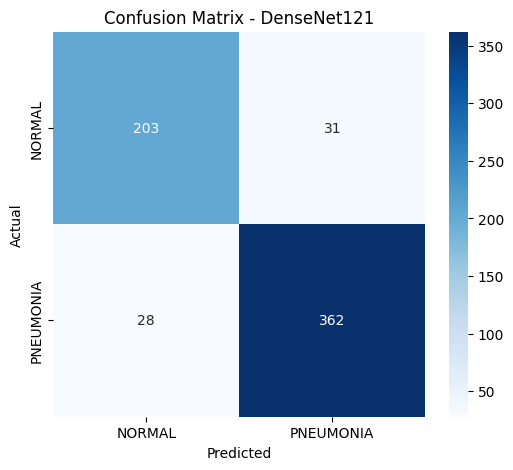

In [ ]:
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")

test_gen.reset()
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DenseNet121')
plt.show()

MODEL TRAINING PERFORMANCE

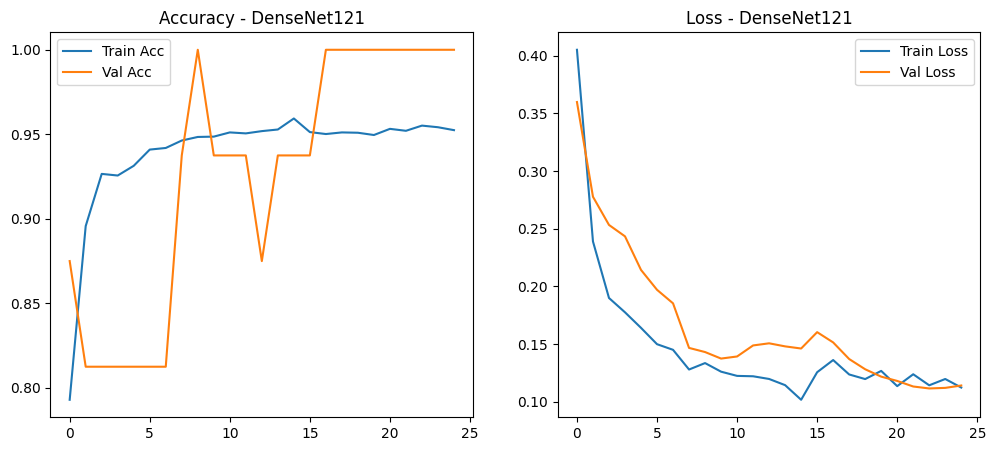

In [ ]:
def plot_history(h1, h2=None):
    acc = h1.history['accuracy']
    val_acc = h1.history['val_accuracy']
    loss = h1.history['loss']
    val_loss = h1.history['val_loss']

    if h2:
        acc += h2.history['accuracy']
        val_acc += h2.history['val_accuracy']
        loss += h2.history['loss']
        val_loss += h2.history['val_loss']

    epochs_range = range(len(acc))
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.legend()
    plt.title('Accuracy - DenseNet121')

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss - DenseNet121')
    plt.show()

plot_history(history, history_fine)

CONCLUSION:This project successfully developed a deep learning model for detecting pneumonia from chest X-ray images. The objective was to classify chest X-ray images into two categories: NORMAL and PNEUMONIA. The dataset was organized into training, validation, and testing sets, and image preprocessing and data augmentation techniques were applied to improve the model's ability to generalize.For classification, the project used MobileNetV2 and DenseNet121. The pretrained MobileNetV2 base model was used with an additional classification layer, allowing the model to learn features relevant to pneumonia detection while reducing the computational requirements compared with training a deep CNN completely from scratch.The model achieved a test accuracy of 90% and an AUC of 96%. The test precision was 88%, while the recall was 97%. The classification report also showed an F1-score of 0.92 for the PNEUMONIA class, indicating that the model was effective at identifying pneumonia cases.